In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-segmentation-dataset/Online Retail.xlsx


# Import Necessary Modules

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

import warnings

warnings.filterwarnings("ignore")

# Read The Data

In [3]:
df = pd.read_excel("/kaggle/input/customer-segmentation-dataset/Online Retail.xlsx")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Check The Data

In [5]:
print("Number of Columns in the Data: ", df.shape[1])
print("Number of Rows in the Data: ", df.shape[0])

Number of Columns in the Data:  8
Number of Rows in the Data:  541909


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

5268

# EDA

In [9]:
des = df.describe().transpose()
palette = sns.color_palette("icefire", as_cmap=True)
des.style.background_gradient(cmap=palette)

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.000000,9.552250,-80995.000000,1.000000,3.000000,10.000000,80995.000000,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,nan
UnitPrice,541909.000000,4.611114,-11062.060000,1.250000,2.080000,4.130000,38970.000000,96.759853
CustomerID,406829.000000,15287.690570,12346.000000,13953.000000,15152.000000,16791.000000,18287.000000,1713.600303


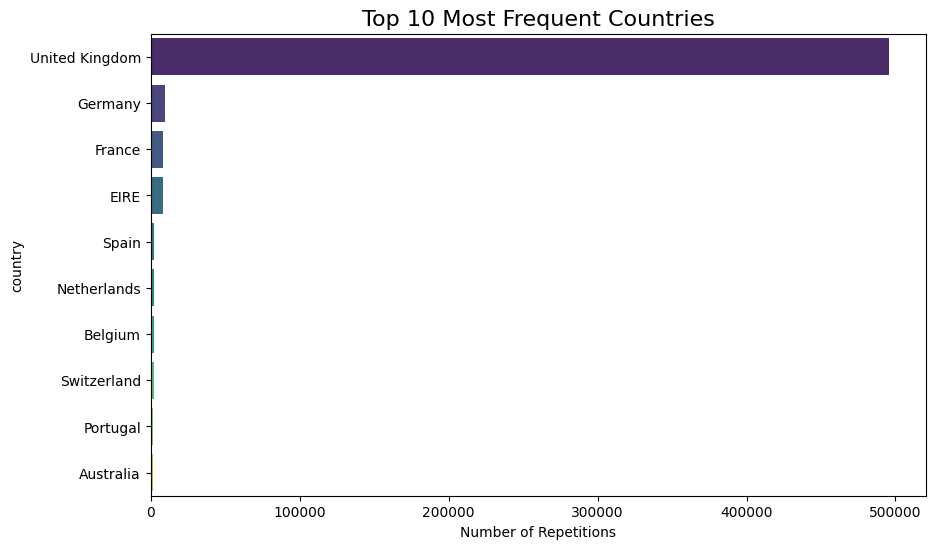

In [10]:
country_count = df.Country.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_count.values, y=country_count.index, palette='viridis')
plt.title("Top 10 Most Frequent Countries", fontsize=16)
plt.xlabel("Number of Repetitions")
plt.ylabel("country")
plt.show()

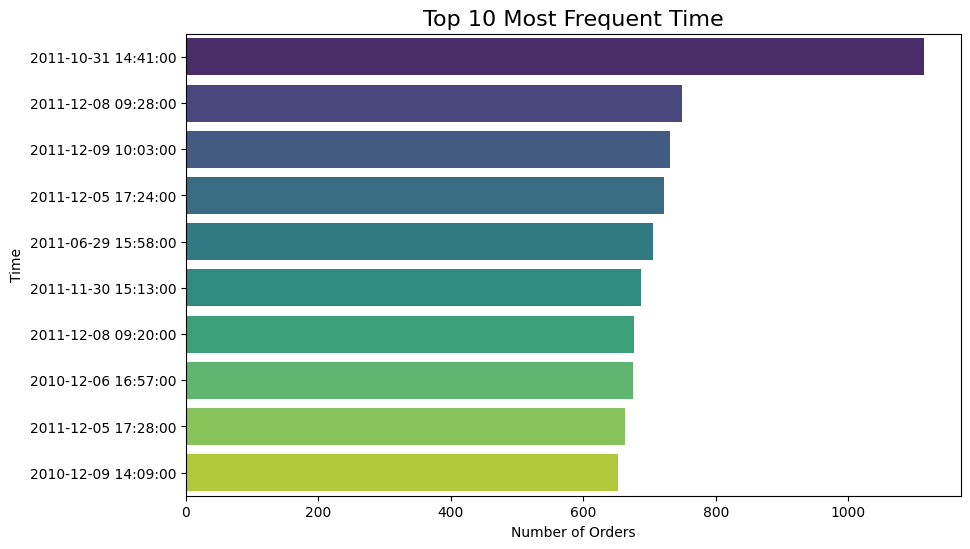

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%Y-%m-%d.%f')
time_triend = df['InvoiceDate'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=time_triend.values, y=time_triend.index, palette='viridis')
plt.title('Top 10 Most Frequent Time', fontsize=16)
plt.xlabel('Number of Orders')
plt.ylabel('Time')
plt.show()

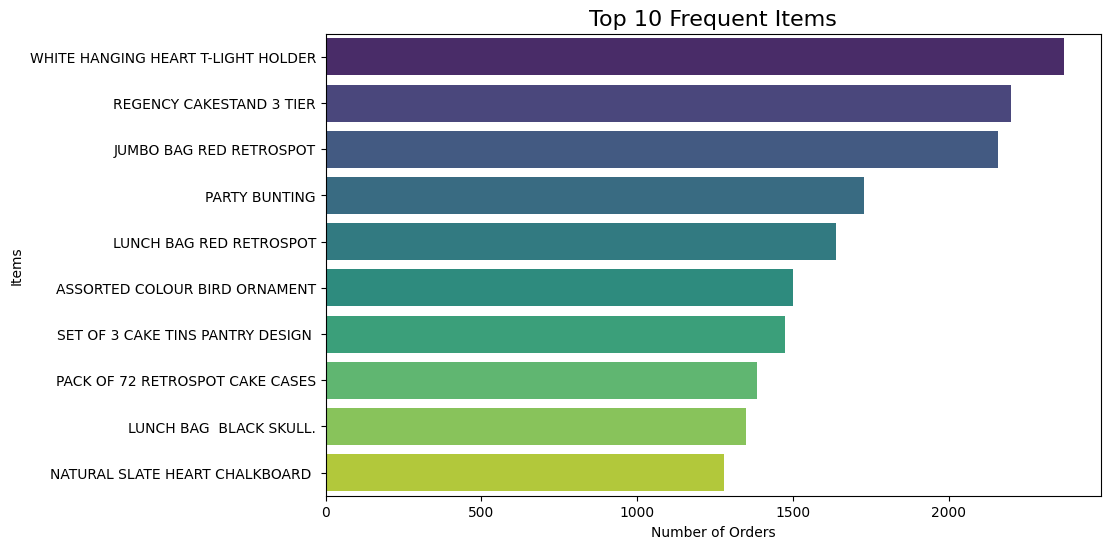

In [12]:
description_count = df["Description"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=description_count.values, y=description_count.index, palette='viridis')
plt.title("Top 10 Frequent Items", fontsize=16)
plt.xlabel("Number of Orders")
plt.ylabel("Items")
plt.show()

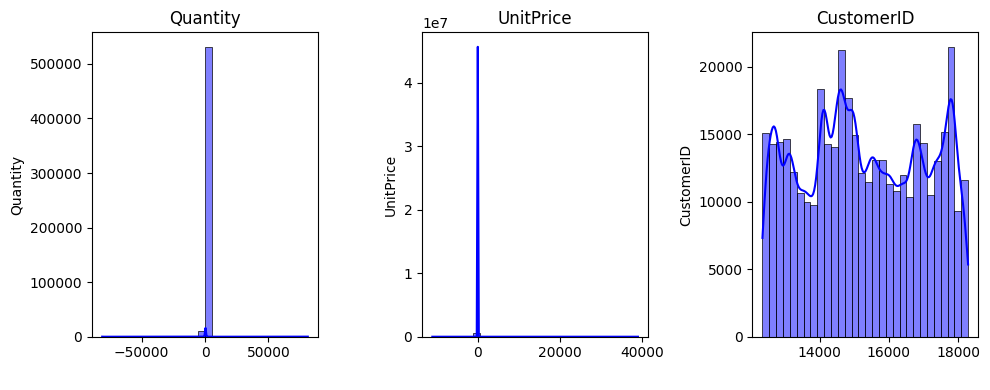

In [13]:
plt.figure(figsize=(10, 4))
for i , feature in enumerate(df.select_dtypes(include="number").columns):
    plt.subplot(1, 3, i+1)
    sns.histplot(data=df, x=df[feature], bins=30, kde=True, color='blue')
    plt.title(f'{feature}')
    plt.xlabel(' ')
    plt.ylabel(feature)
plt.tight_layout()

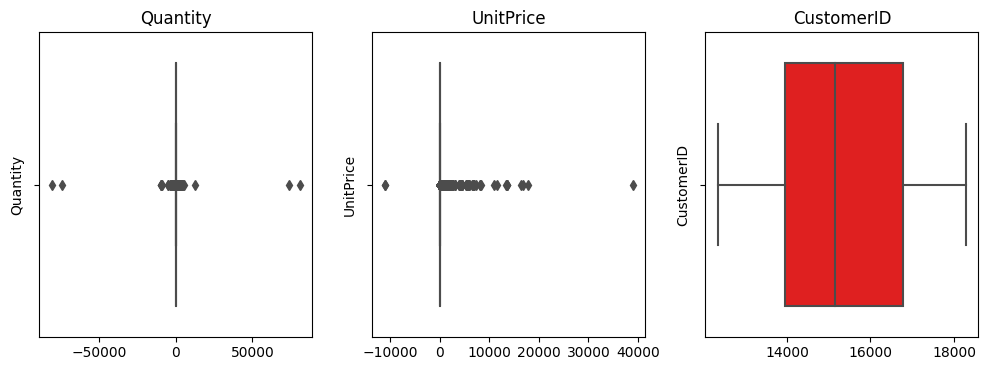

In [14]:
plt.figure(figsize=(10, 4))
for i, feature in enumerate(df.select_dtypes(include="number").columns):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x=df[feature], color='red')
    plt.title(f'{feature}')
    plt.xlabel(' ')
    plt.ylabel(f'{feature}')
plt.tight_layout()

# Garbage Treatment

In [15]:
df.drop_duplicates(inplace=True)

# Outliers Treatment

In [16]:
# there is no country called israel
# that is outlier

def remove_non_existent_country(text):
    if text == "Israel":
        text = "Palestine"
    return text

df["Country"] = df["Country"].apply(remove_non_existent_country)

In [17]:
q1 = df["Quantity"].quantile(0.30)
q3 = df["Quantity"].quantile(0.70)
iqr = q3 - q1

upper_limit = q3 + (1.5 * iqr)
lower_limit = q1 - (1.5 * iqr)

df = df.loc[(df["Quantity"] < upper_limit) & (df["Quantity"] > lower_limit)]

In [18]:
q1 = df["UnitPrice"].quantile(0.25)
q3 = df["UnitPrice"].quantile(0.65)
iqr = q3 - q1

upper_limit = q3 + (1.5 * iqr)
lower_limit = q1 - (1.5 * iqr)

df = df.loc[(df["UnitPrice"] < upper_limit) & (df["UnitPrice"] > lower_limit)]

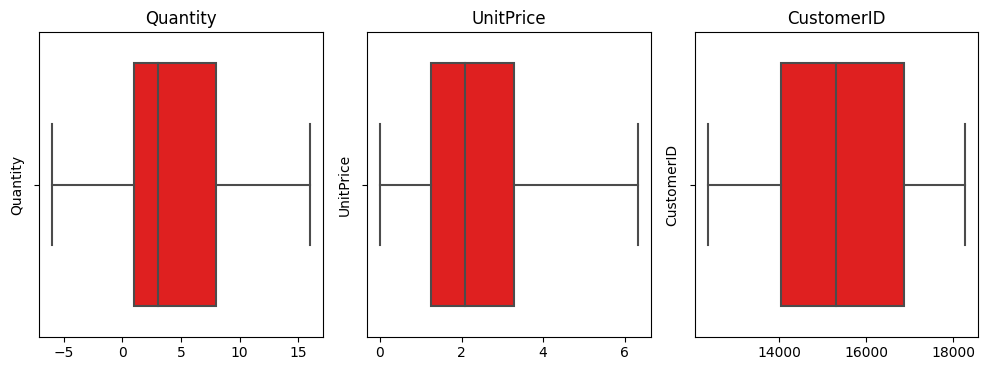

In [19]:
plt.figure(figsize=(10, 4))
for i, feature in enumerate(df.select_dtypes(include="number").columns):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x=df[feature], color='red')
    plt.title(f'{feature}')
    plt.xlabel(' ')
    plt.ylabel(f'{feature}')
plt.tight_layout()

# Encoding

In [20]:
X = df[["Quantity", "UnitPrice", "Country"]]

In [21]:
encoder = LabelEncoder()

X["Country"] = encoder.fit_transform(X["Country"])

# Missing Values Treatment

In [22]:
X.dropna(inplace=True)

In [23]:
X.isnull().sum()

Quantity     0
UnitPrice    0
Country      0
dtype: int64

# Feature Engineering

In [24]:
X["total_price"] = X["Quantity"] * X["UnitPrice"]

In [25]:
X

,Quantity,UnitPrice,Country,total_price
0,6,2.55,36,15.30
1,6,3.39,36,20.34
2,8,2.75,36,22.00
3,6,3.39,36,20.34
4,6,3.39,36,20.34
...,...,...,...,...
541904,12,0.85,13,10.20
541905,6,2.10,13,12.60
541906,4,4.15,13,16.60
541907,4,4.15,13,16.60


# Correlation Matrix

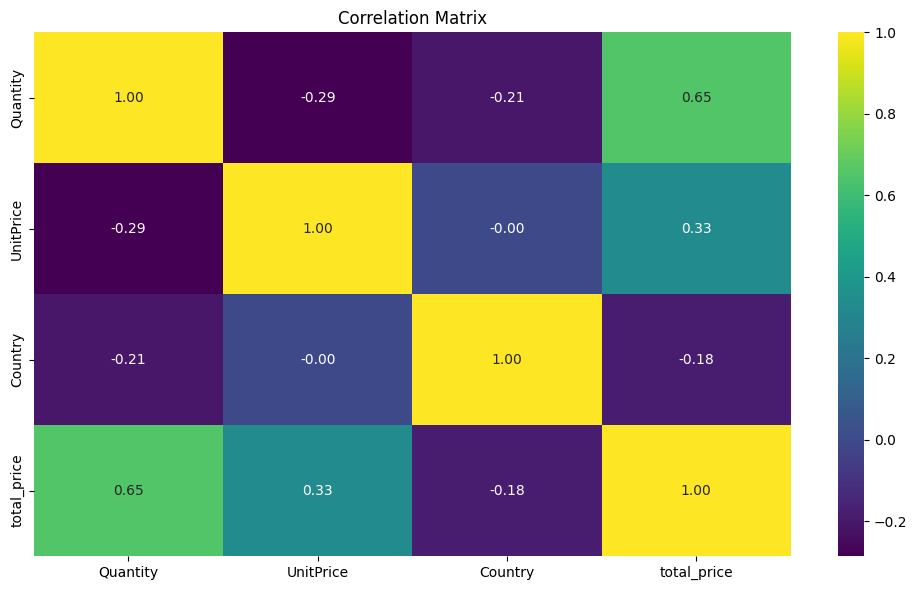

In [26]:
corr = X.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Scaling

In [27]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

# Clustering

In [28]:
wcss = []
for i in range(2, 11):
    kmeans = KMeans(i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

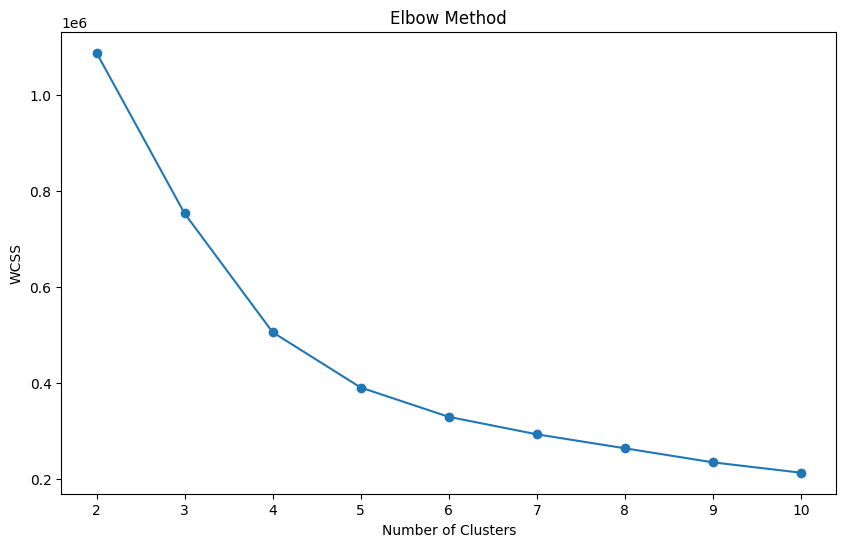

In [29]:
# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [30]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

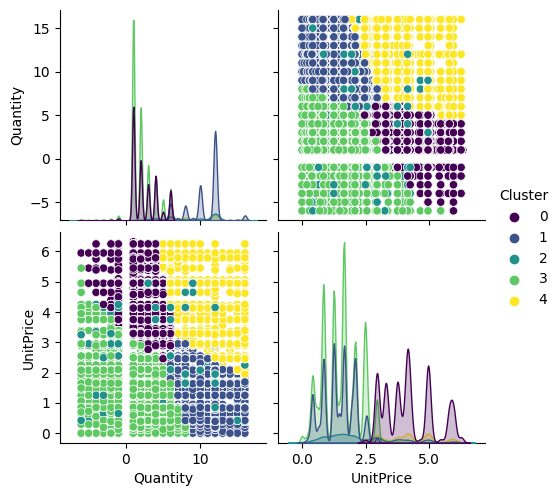

In [31]:
sns.pairplot(df, hue='Cluster', vars=['Quantity', 'UnitPrice',], palette='viridis')
plt.show()